In [254]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import pickle
import pandas as pd
import utils
from functools import partial
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [255]:
POI_FILENAME = "../data/poi-paris.pkl"
parismap = mpimg.imread('../data/paris-48.806-2.23--48.916-2.48.jpg')
## coordonnees GPS de la carte
xmin, xmax = 2.23, 2.48  # coord_x min et max
ymin, ymax = 48.806, 48.916  # coord_y min et max
coords = [xmin, xmax, ymin, ymax]

bars, bar_notes = utils.load_poi("bar")
restos, resto_notes = utils.load_poi("restaurant")
clubs, club_notes = utils.load_poi("night_club")

# Data

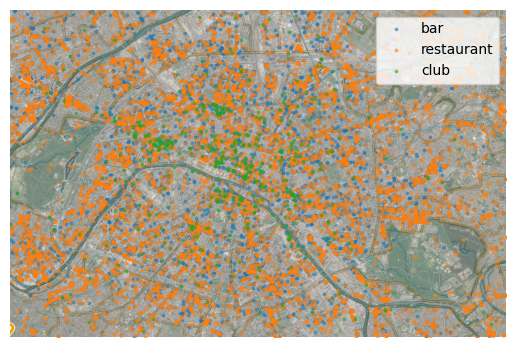

In [256]:
# Data:
utils.show_img()
# Affiche les POIs
plt.scatter(bars[:,0],bars[:,1],alpha=0.5,s=3, label="bar")
plt.scatter(restos[:,0],restos[:,1],alpha=0.5,s=3, label="restaurant")
plt.scatter(clubs[:,0],clubs[:,1],alpha=0.5,s=3, label="club")
plt.axis("off")
plt.legend()
plt.show()

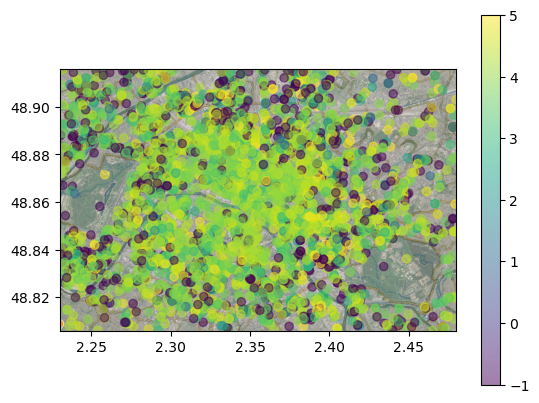

In [257]:
utils.show_img()
plt.scatter(bars[:,0], bars[:, 1], c=bar_notes, alpha=0.5)
plt.colorbar()
plt.show()

# Histogram

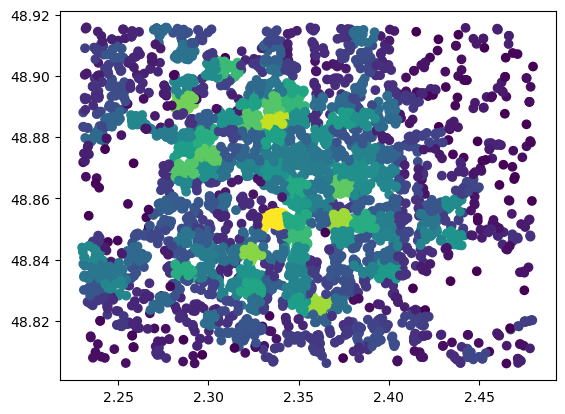

In [258]:
data = bars
hist = utils.Histogramme(20)

hist.fit(data)
plt.scatter(data[:,0], data[:, 1], c=hist.predict(bars))

Density estimator must integrate to one over the corrdinate domain.

In [259]:
dens, xlin, ylin = utils.get_density2D(hist, data, steps=20)
bin_area = np.diff(xlin[:2]) * np.diff(ylin[:2])
print(f"Density integrates to: {(dens).sum()*bin_area}")

Density integrates to: [1.10803324]


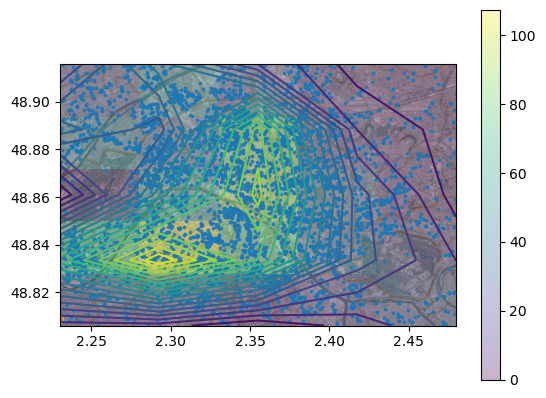

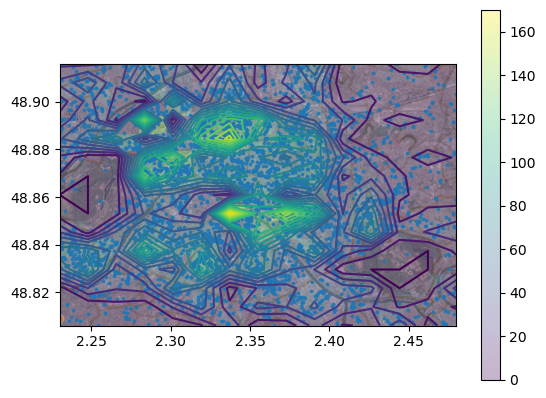

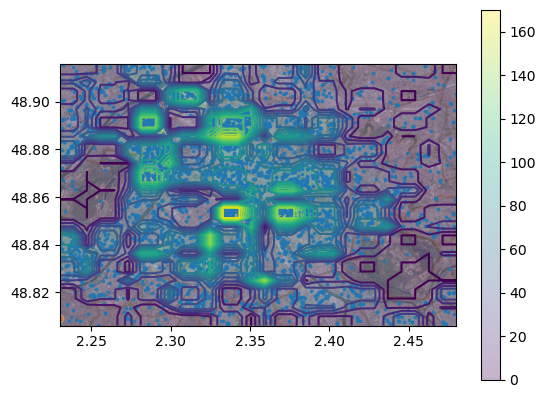

In [260]:
for steps in (5, 15, 30):
    utils.show_density(hist, data, steps=steps)

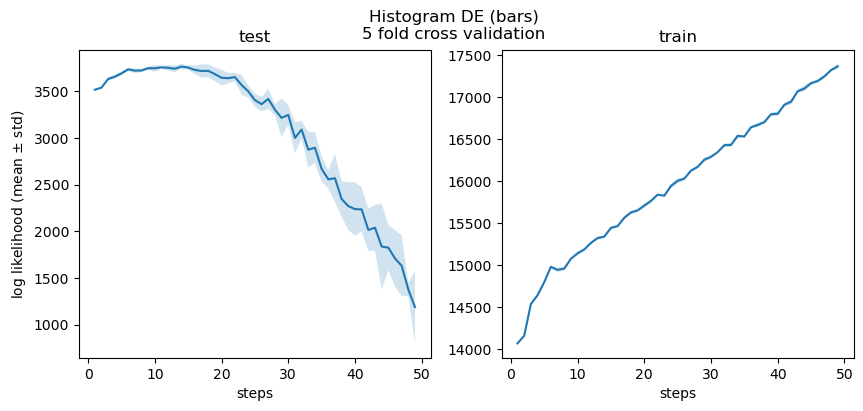

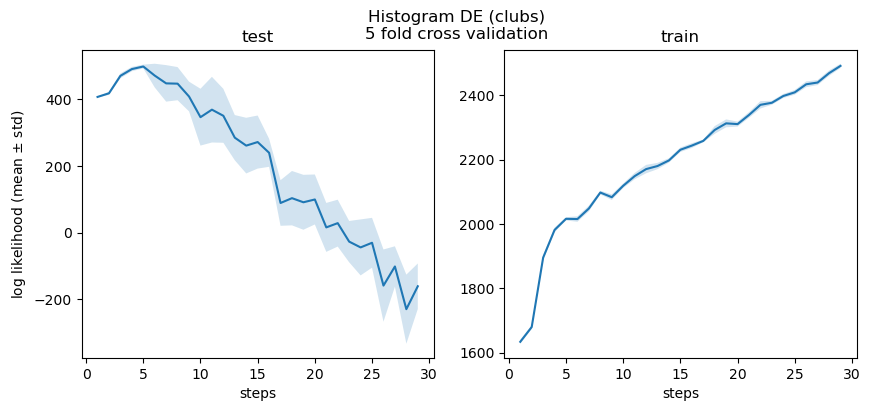

In [261]:
utils.cross_validate(utils.Histogramme, 
                     data=bars, 
                     params=np.arange(1,50),
                     folds=5,
                     param_name="steps",
                     title="Histogram DE (bars)")
utils.cross_validate(utils.Histogramme, 
                     data=clubs, 
                     params=np.arange(1,30),
                     folds=5,
                     param_name="steps",
                     title="Histogram DE (clubs)")

For bars, 10-15 histrogram bins show the best performance (highest likelihood of test dataset). For clubs (rare), optimal number of steps is around 5.

In [ ]:
hist = utils.Histogramme(steps=5)
hist.fit(clubs)
utils.show_density(hist, clubs, steps=steps)

NameError: name 'utils' is not defined

# Kernel Density Estimation

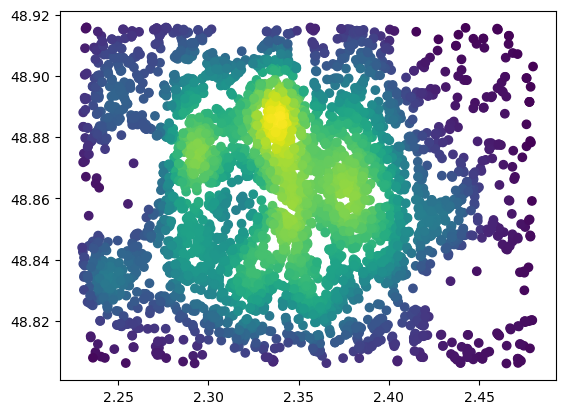

In [263]:
kde = utils.KernelDensity(kernel=utils.kernel_gaussian, sigma=0.01)
data = bars#[:500,:]
kde.fit(data)
kde.predict(data)
kde_density = kde.predict(data)
# kde_density
plt.scatter(data[:,0], data[:, 1], c=kde_density)
plt.show()

In [264]:
dens, xlin, ylin = utils.get_density2D(hist, data, steps=100)
bin_area = np.diff(xlin[:2]) * np.diff(ylin[:2])
print(f"Density integrates to: {(dens).sum()*bin_area}")

Density integrates to: [1.02137712]


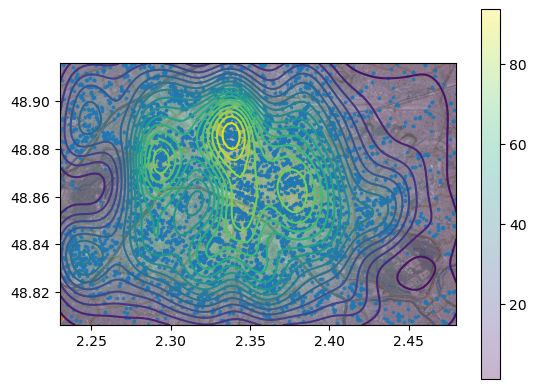

In [265]:
utils.show_density(kde,data)

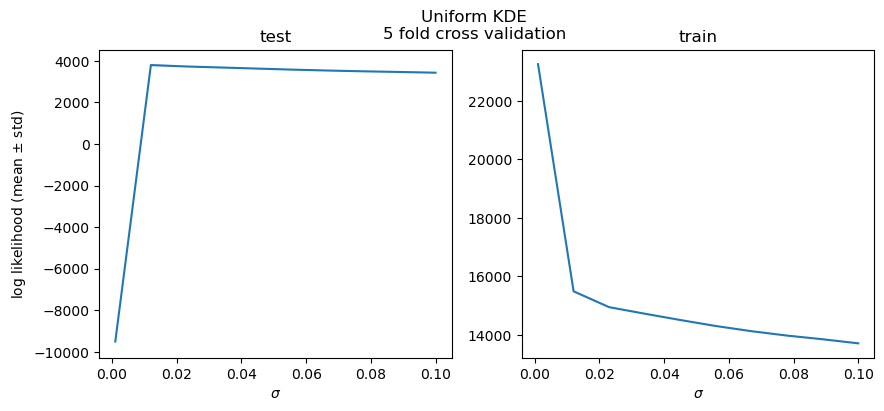

In [266]:
utils.cross_validate(estimator= partial(utils.KernelDensity, kernel= utils.kernel_uniform),
                     data=data, 
                     params=np.linspace(0.001, 0.1, 10),
                     param_name = "$\\sigma$",
                     title="Uniform KDE", 
                     folds=5)

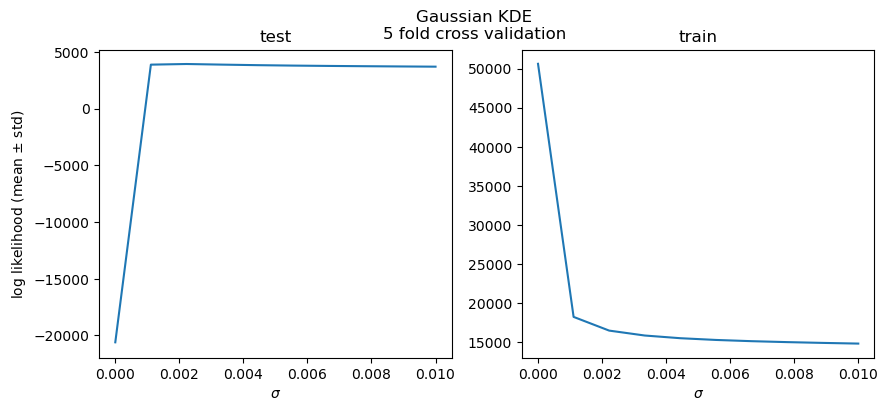

In [267]:
utils.cross_validate(estimator= partial(utils.KernelDensity, kernel= utils.kernel_gaussian),
                     data=data, 
                     params=np.linspace(0.00001, 0.01, 10),
                     param_name = "$\\sigma$",
                     title="Gaussian KDE",
                     folds=5)

# Nadaraya-Watson Estimator

In [268]:
nw = utils.Nadaraya(sigma = 0.05, kernel=utils.kernel_gaussian)
nw.fit(bars, bar_notes)
nw.predict(bars)

array([3.23129252, 3.04060223, 3.1818199 , ..., 3.14733324, 3.25208842,
       3.19778314], shape=(4888,))

<string>:7: RuntimeWarning: invalid value encountered in divide


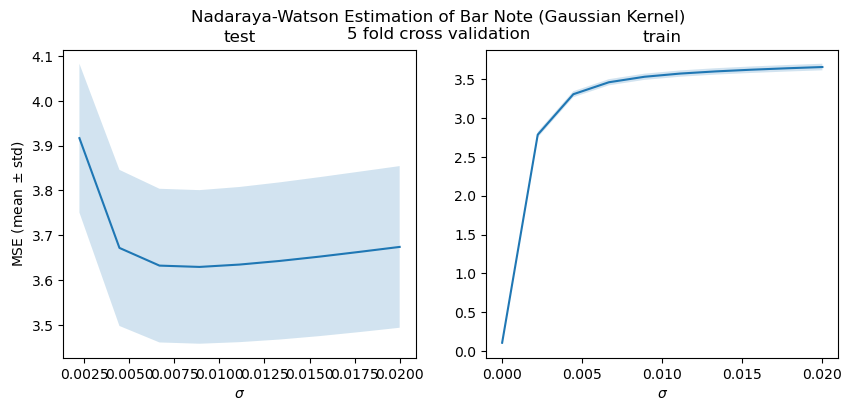

In [269]:
utils.cross_validate(estimator= partial(utils.Nadaraya, kernel= utils.kernel_gaussian),
                     data=bars, 
                     y = bar_notes,
                     params=np.linspace(0.00001, 0.02, 10),
                     param_name = "$\\sigma$",
                     title="Nadaraya-Watson Estimation of Bar Note (Gaussian Kernel)",
                     folds=5)

# Covid Pandas

In [270]:
covid_df = pd.read_csv("../data/sp-fra-jour-2023-06-30-16h26.csv", sep=";", decimal=",")

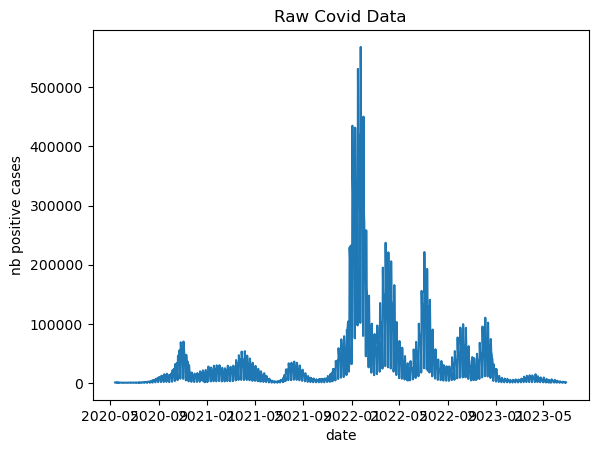

In [271]:
covid_df["jour"] = pd.to_datetime(covid_df["jour"], format="%Y-%m-%d")
covid_df = covid_df.sort_values("jour")
plt.plot(covid_df["jour"],covid_df["P"])
plt.xlabel("date")
plt.ylabel("nb positive cases")
plt.title("Raw Covid Data")
plt.show()

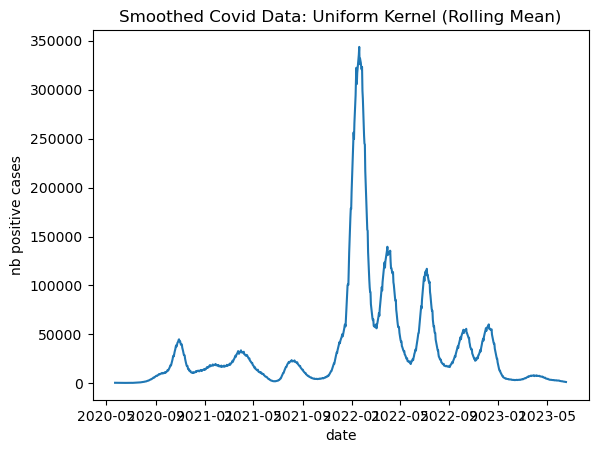

In [272]:
p_smooth = (
    covid_df["P"].
    rolling(window=20, center=True).
    mean() # equal weights, just the mean
)
plt.plot(covid_df["jour"],p_smooth)
plt.xlabel("date")
plt.ylabel("nb positive cases")
plt.title("Smoothed Covid Data: Uniform Kernel (Rolling Mean)")
plt.show()

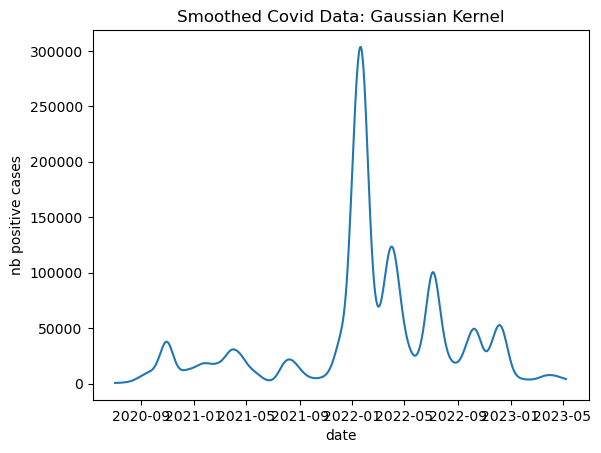

In [273]:
p_smooth = (
    covid_df["P"].
    rolling(window=100, win_type="gaussian", center=True).
    mean(std=10) # weighted mean since Gaussian window
)
plt.plot(covid_df["jour"],p_smooth)
plt.xlabel("date")
plt.ylabel("nb positive cases")
plt.title("Smoothed Covid Data: Gaussian Kernel")
plt.show()